In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from MDAnalysis.analysis.rdf import InterRDF
import MDAnalysis as mda
from MDAnalysis.analysis import rdf

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# Color mapping for sizes
size_colors = {'small': '#e74c3c', 'medium': '#27ae60', 'large': '#f39c12'}

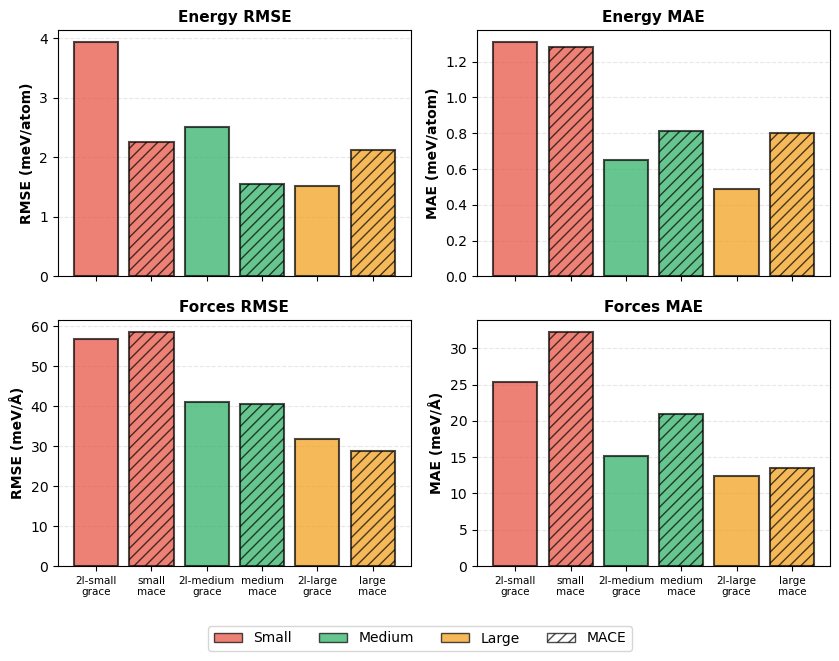

In [31]:
##### Final Plots for Energies and Forces #####

# Load data
# There are two possible files, energies_per_atom -> structures seen by GRACE and MACE, energies_per_atom_ood -> structure NOT seen by GRACE
df = pd.read_csv('energies/energies_per_atom_ood.csv')

# Extract layers and size
df['layers'] = df['size'].str.extract(r'(\d+l)')[0]
df['model_size'] = df['size'].str.extract(r'_(\w+)$')[0]

# Filter for 2-layer models only (2l GRACE and MACE)
df = df[(df['layers'] == '2l') | (df['model'] == 'mace')].copy()

# Sort order: group by size (small, medium, large), then within each size: GRACE first, then MACE
def get_sort_key(row):
    size_order = {'small': 0, 'medium': 1, 'large': 2}
    model_order = {'grace': 0, 'mace': 1}
    return (size_order[row['model_size']], model_order[row['model']])

df['sort_keys'] = df.apply(get_sort_key, axis=1)
df = df.sort_values('sort_keys').reset_index(drop=True)
df = df.drop('sort_keys', axis=1)

# Create x-axis labels: include size and layer info
df['x_label'] = df.apply(
    lambda row: f"{row['model_size']}\n{row['model']}" if row['model'] == 'mace' 
    else f"{row['layers']}-{row['model_size']}\n{row['model']}", 
    axis=1
)

# Create 2x2 subplot with shared x-axis
fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), sharex=True)
axes = axes.flatten()

# Metrics to plot: (column_name, title, ylabel, unit)
metrics = [
    ('energy_rmse_meV', 'Energy RMSE', 'RMSE (meV/atom)'),
    ('energy_mae_meV', 'Energy MAE', 'MAE (meV/atom)'),
    ('forces_rmse_meV_per_A', 'Forces RMSE', 'RMSE (meV/Å)'),
    ('forces_mae_meV_per_A', 'Forces MAE', 'MAE (meV/Å)')
]

# Plot each metric
for idx, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[idx]
    
    # Get unique x positions
    x_positions = np.arange(len(df))
    
    # Create bars with colors based on size
    colors = [size_colors[size] for size in df['model_size']]
    
    # Highlight MACE models with hatching pattern
    hatches = ['///' if model == 'mace' else '' for model in df['model']]
    
    bars = ax.bar(x_positions, df[metric], color=colors, alpha=0.7, 
                  edgecolor='black', linewidth=1.5)
    
    # Apply hatching to MACE bars
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    
    # Customize plot
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(df['x_label'], fontsize=7.5, rotation=0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

# Create legend for sizes and MACE pattern at the bottom
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=size_colors[size], label=size.capitalize(), 
                         edgecolor='black', alpha=0.7) 
                   for size in ['small', 'medium', 'large']]
# Add MACE hatching pattern to legend
legend_elements.append(Patch(facecolor='white', label='MACE', 
                             edgecolor='black', hatch='///', alpha=0.7))
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.02), fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("energies_ood_all.pdf", bbox_inches='tight')
plt.show()

In [32]:
traj = {
    "2l-small grace": "traj/traj_water_npt_300_2l_grace_small.pdb",
    "2l-medium grace": "traj/traj_water_npt_300_2l_grace_medium.pdb",
}


model_rdf = dict()

for model, path in traj.items():

    u = mda.Universe(path)

    irdf2 = dict()

    oxygen = u.select_atoms("name O*")
    hydrogen = u.select_atoms("name H*")

    for i, combination in enumerate(["o-o", "o-h", "h-h"]):
        if combination == "o-o":
            group1 = oxygen
            group2 = oxygen
            exclusion_block = (1, 1)
        elif combination == "o-h":
            group1 = oxygen
            group2 = hydrogen
            exclusion_block = (1, 2)
        elif combination == "h-h":
            group1 = hydrogen
            group2 = hydrogen
            exclusion_block = (2, 2)

        irdf2[combination] = InterRDF(
            group1,
            group2,
            nbins=75,  # default
            range=(0.0, 12.0),  # distance in angstroms
            exclusion_block=exclusion_block,  # exclude intramolecular pairs
        )
        irdf2[combination].run(step=100)

    model_rdf[path] = irdf2

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


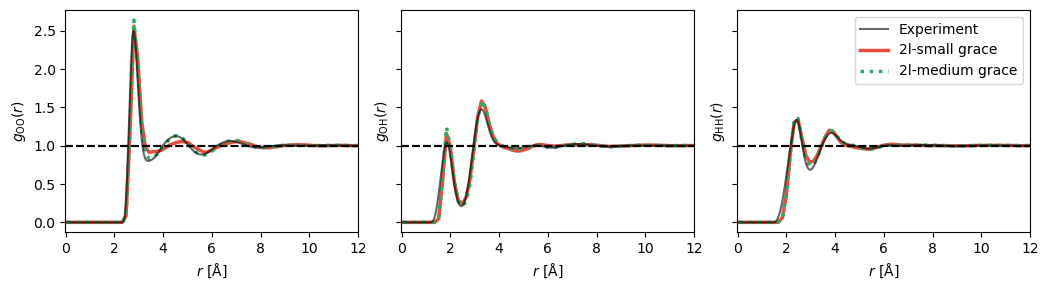

In [50]:
# water data ----------------------------------

exp_water = pd.read_csv("../data/exp_data/exp_water.dat", delimiter="\t")
r_A = exp_water[" r[A] "]
rdf_exp_OO = exp_water["O–O "]
rdf_exp_Oh = exp_water["O–H "]
rdf_exp_hh = exp_water["H–H "]
xlim_lower, xlim_upper = -0.2, 10

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3), sharey=True)
axes[0].plot(r_A, rdf_exp_OO, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)
axes[1].plot(r_A, rdf_exp_Oh, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)
axes[2].plot(r_A, rdf_exp_hh, label="Experiment", color="black", linewidth=1.5, linestyle='-', zorder=10, alpha=0.6)


ylabel_map = {"o-o": r"$g_{\mathrm{OO}}(r)$", "o-h": r"$g_{\mathrm{OH}}(r)$", "h-h": r"$g_{\mathrm{HH}}(r)$"}

# Extract size from model name for color mapping and assign different line styles
model_colors = {}
model_linestyles = {}
linestyles = ['-', ':', '-.', ':']  # solid, dashed, dash-dot, dotted
for idx, model in enumerate(traj.keys()):
    if 'small' in model:
        model_colors[model] = size_colors['small']
    elif 'medium' in model:
        model_colors[model] = size_colors['medium']
    elif 'large' in model:
        model_colors[model] = size_colors['large']
    model_linestyles[model] = linestyles[idx % len(linestyles)]

for model, path in traj.items():
    rdf = model_rdf[path]
    for i, combination in enumerate(["o-o", "o-h", "h-h"]):

        axes[i].plot(
            rdf[combination].results.bins,
            rdf[combination].results.rdf,
            label=model,
            color=model_colors[model],
            linestyle=model_linestyles[model],
            alpha=1,
            linewidth=2.5,
        )
        axes[i].axhline(y=1, color="k", linestyle="--")
        axes[i].set_xlabel(r"$r$ [Å]")
        axes[i].set_ylabel(ylabel_map[combination])
        axes[i].set_xlim(-0.01, 12)
        axes[2].legend()

plt.tight_layout()
plt.savefig("waterbox_rdf_comparison_exp.png", dpi=300)
plt.show()